# 🔍 Exploratory Data Analysis — Synthetic Fraud Dataset

This notebook covers:
1. Basic Info — shape, dtypes, missing values
2. Distribution Plots — histograms & boxplots
3. Correlation Heatmap
4. Fraud vs Non-Fraud Comparisons
5. Outlier Detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

FRAUD_COLOR = '#e74c3c'
LEGIT_COLOR = '#2ecc71'

df = pd.read_csv('synthetic_fraud_dataset.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset loaded: 10,000 rows × 10 columns


,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


---
## 1. Basic Info

In [2]:
print('=== Shape ===')
print(f'{df.shape[0]:,} rows, {df.shape[1]} columns\n')

print('=== Data Types ===')
print(df.dtypes.to_string())

print('\n=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df.to_string())
print('\n✅ No missing values!' if missing.sum() == 0 else f'\n⚠️ {missing.sum()} missing values found!')

=== Shape ===
10,000 rows, 10 columns

=== Data Types ===
transaction_id         int64
user_id                int64
amount               float64
transaction_type      object
merchant_category     object
country               object
hour                   int64
device_risk_score    float64
ip_risk_score        float64
is_fraud               int64

=== Missing Values ===
                   Missing Count  Missing %
transaction_id                 0        0.0
user_id                        0        0.0
amount                         0        0.0
transaction_type               0        0.0
merchant_category              0        0.0
country                        0        0.0
hour                           0        0.0
device_risk_score              0        0.0
ip_risk_score                  0        0.0
is_fraud                       0        0.0

✅ No missing values!


In [3]:
print('=== Descriptive Statistics (Numerical) ===')
df.describe().round(4)

=== Descriptive Statistics (Numerical) ===


,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.000
mean,4999.5000,500.0587,178.1428,14.2471,0.1838,0.1847,0.050
std,2886.8957,288.3285,531.6480,5.3474,0.1774,0.1758,0.218
min,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.000
25%,2499.7500,247.0000,65.0848,10.0000,0.0757,0.0778,0.000
50%,4999.5000,503.0000,101.6865,14.0000,0.1566,0.1583,0.000
75%,7499.2500,750.2500,138.2809,19.0000,0.2349,0.2370,0.000
max,9999.0000,999.0000,11628.2139,23.0000,0.9987,0.9996,1.000


In [4]:
print('=== Categorical Columns ===')
cat_cols = ['transaction_type', 'merchant_category', 'country']
for col in cat_cols:
    print(f'\n{col}: {df[col].nunique()} unique values')
    print(df[col].value_counts().to_string())

=== Categorical Columns ===

transaction_type: 4 unique values
transaction_type
POS       2568
ATM       2529
QR        2506
Online    2397

merchant_category: 5 unique values
merchant_category
Food           2023
Travel         2015
Electronics    2007
Clothing       1982
Grocery        1973

country: 6 unique values
country
US    2050
FR    2027
UK    1965
DE    1930
TR    1928
NG     100


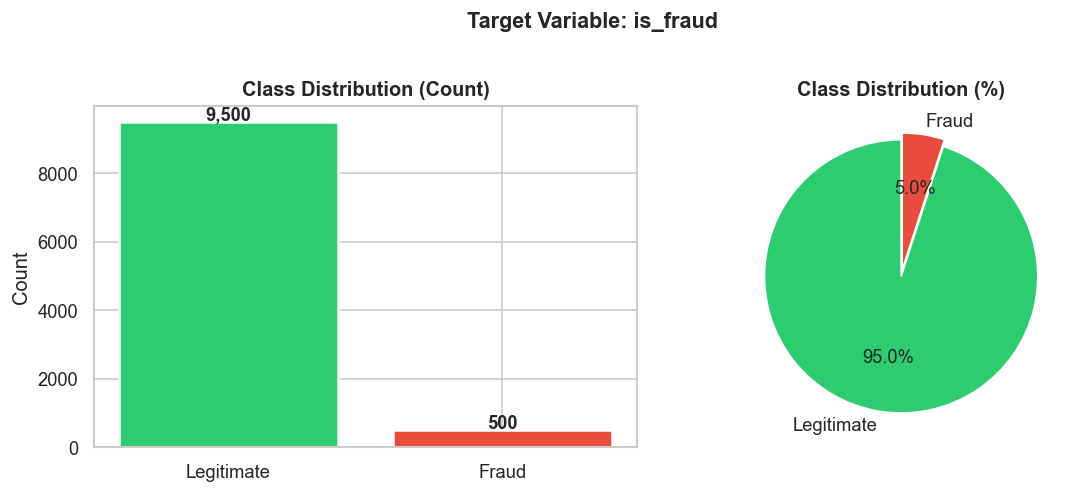


Class imbalance ratio: 1 fraud per 19 legitimate transactions


In [5]:
# Target class distribution
fraud_counts = df['is_fraud'].value_counts()
fraud_pct = df['is_fraud'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
bars = axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values,
                   color=[LEGIT_COLOR, FRAUD_COLOR], edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, fraud_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'],
            colors=[LEGIT_COLOR, FRAUD_COLOR], autopct='%1.1f%%',
            startangle=90, explode=[0, 0.05])
axes[1].set_title('Class Distribution (%)', fontweight='bold')

plt.suptitle('Target Variable: is_fraud', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'\nClass imbalance ratio: 1 fraud per {fraud_counts[0]//fraud_counts[1]} legitimate transactions')

---
## 2. Distribution Plots

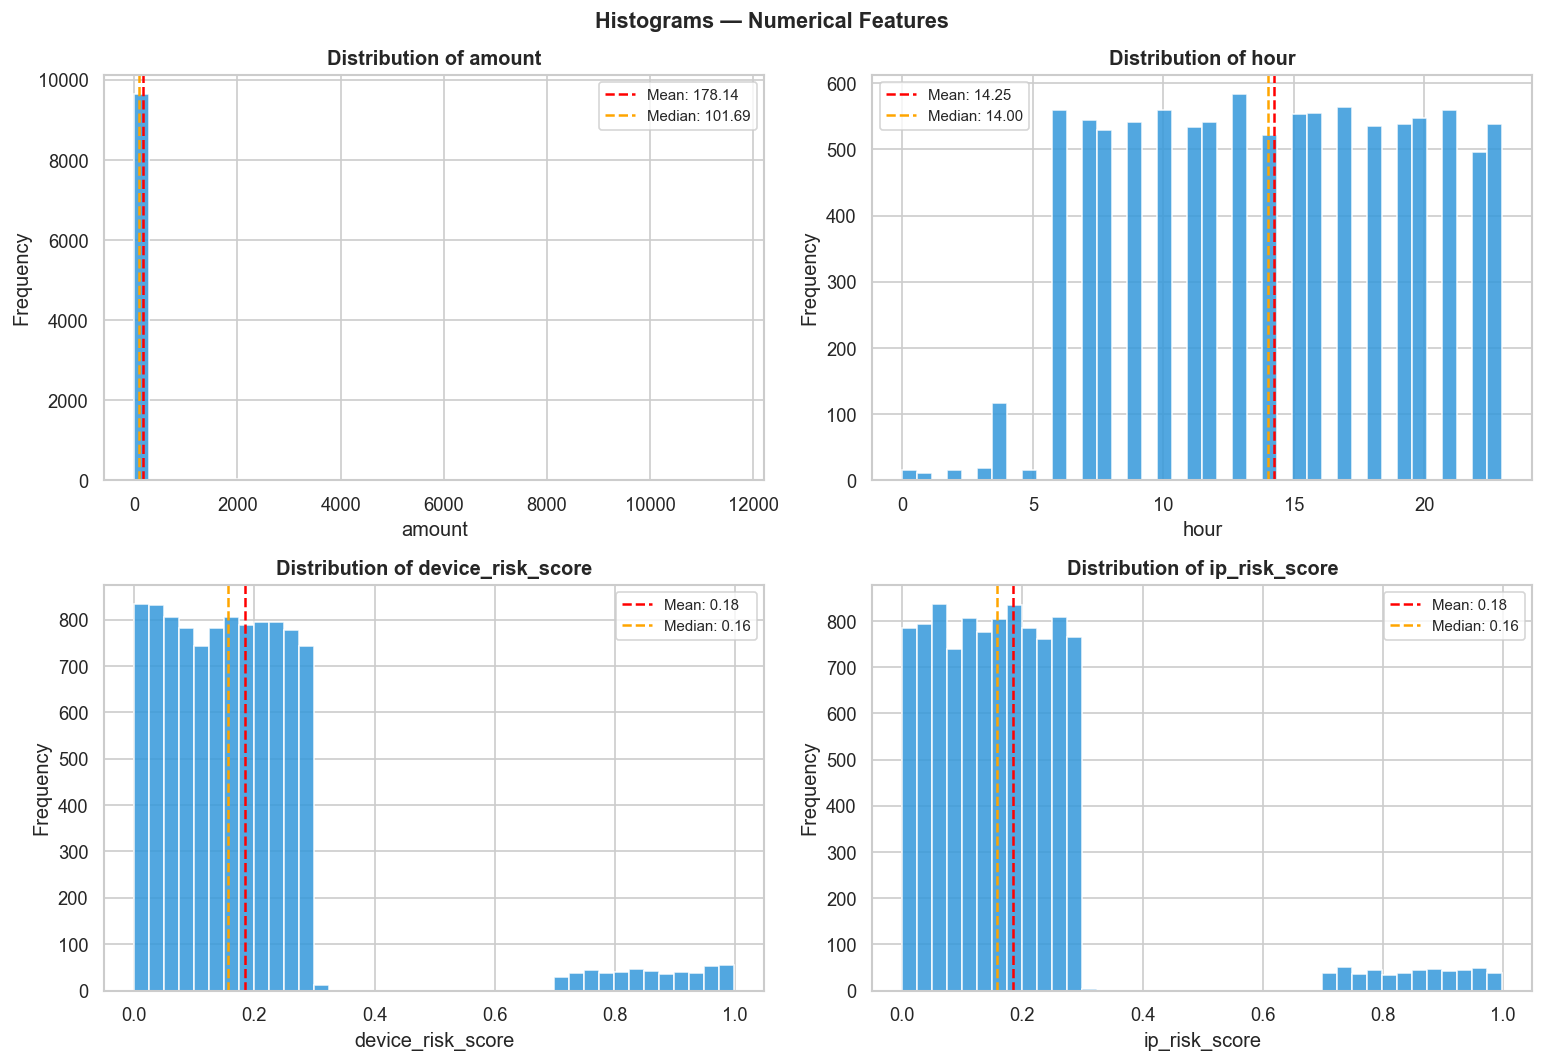

In [6]:
# Histograms for numerical features
num_cols = ['amount', 'hour', 'device_risk_score', 'ip_risk_score']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='#3498db', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df[col].median():.2f}')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

plt.suptitle('Histograms — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

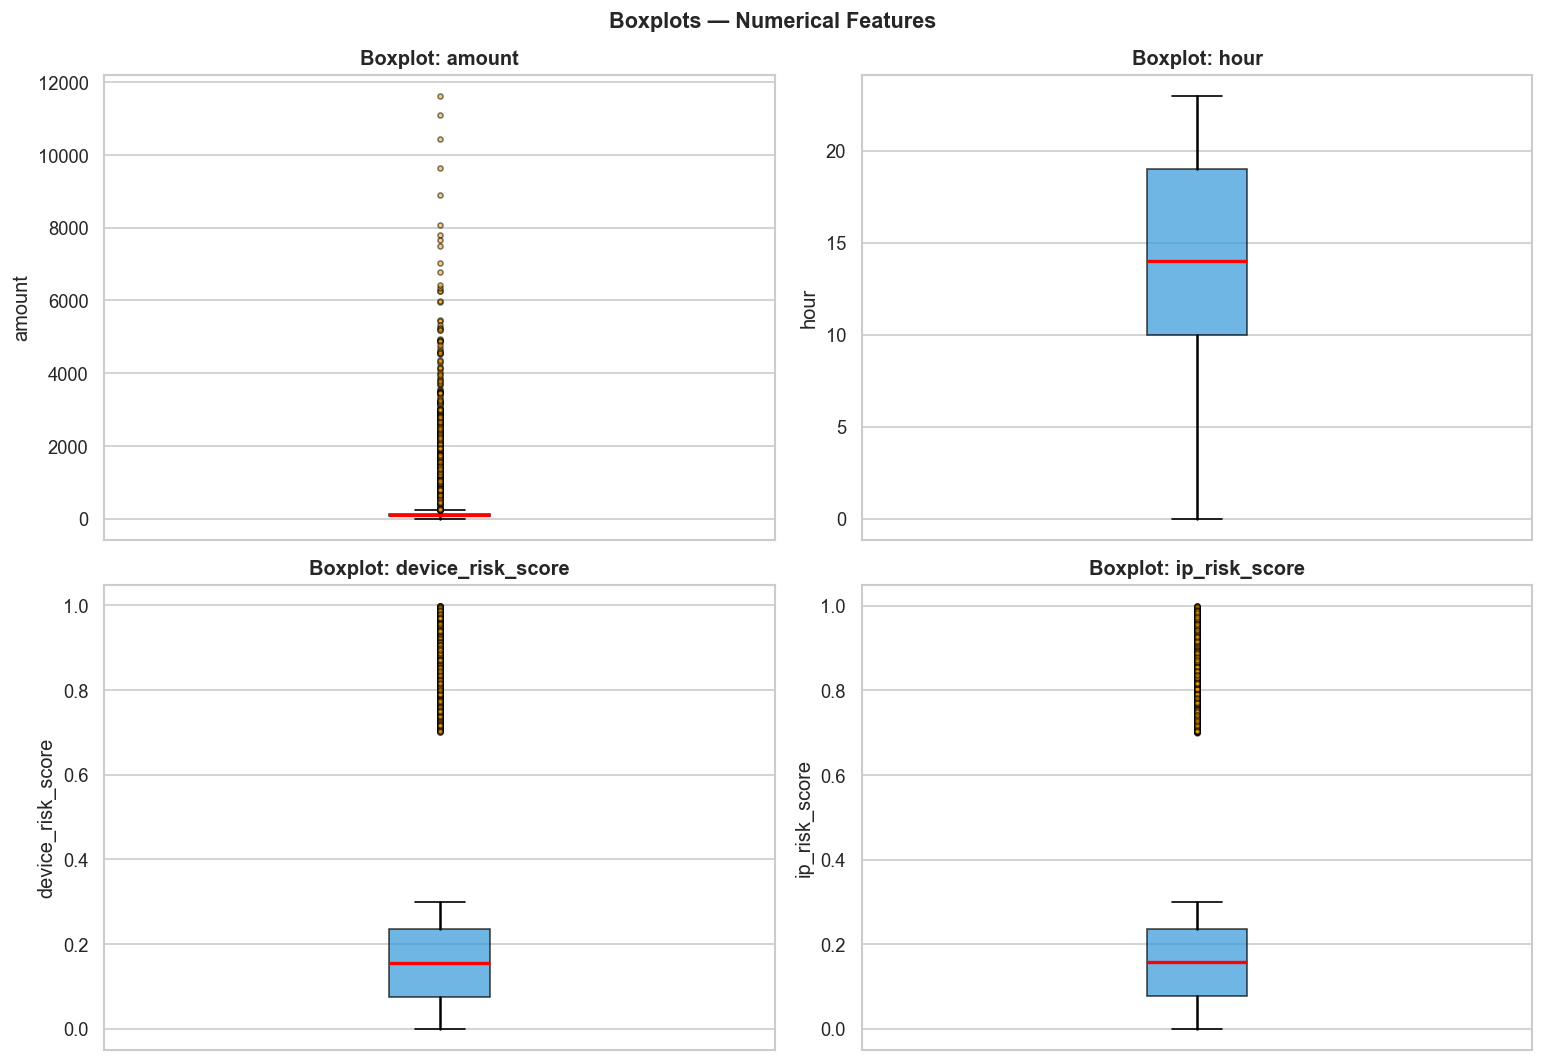

In [7]:
# Boxplots for numerical features
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor='orange', markersize=3, alpha=0.5))
    axes[i].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[i].set_ylabel(col)
    axes[i].set_xticks([])

plt.suptitle('Boxplots — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

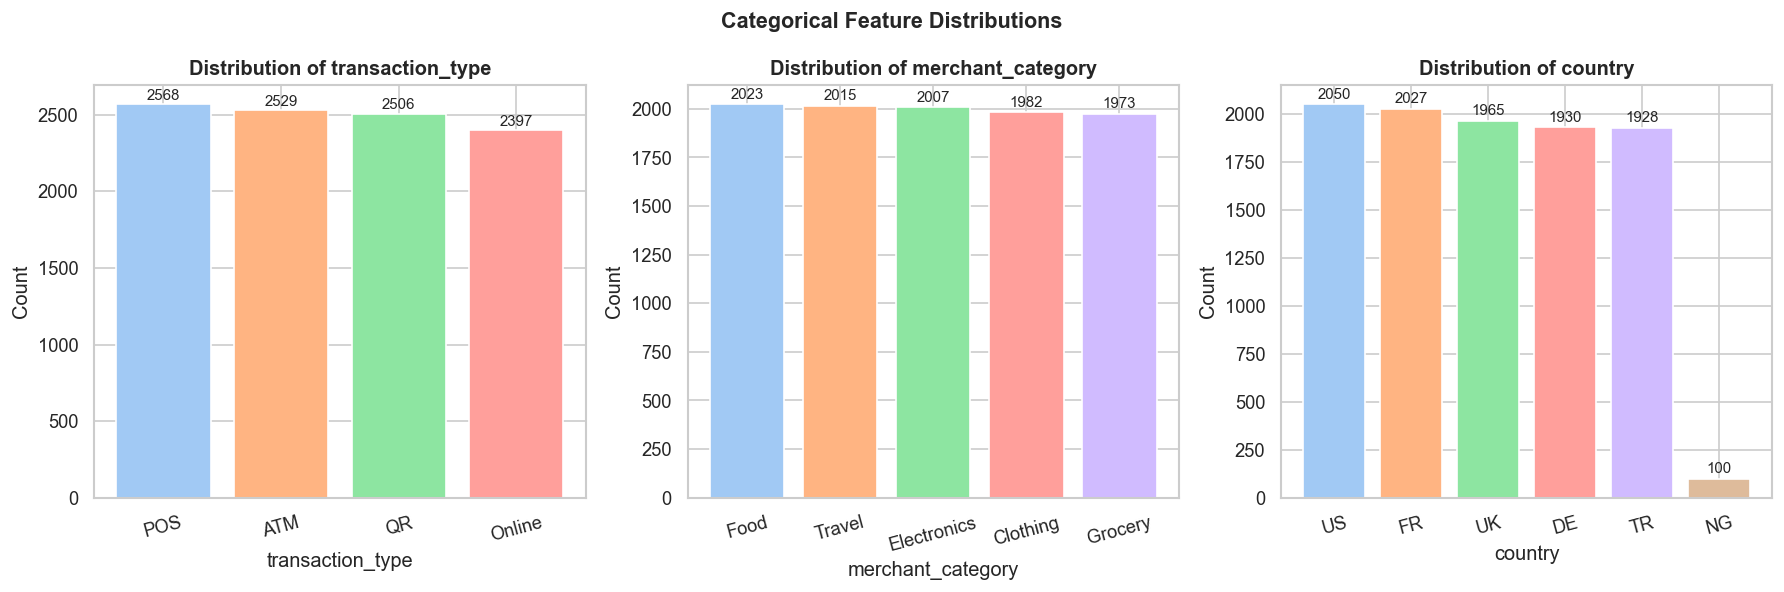

In [8]:
# Categorical feature distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = sns.color_palette('pastel', 6)

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=colors[:len(counts)], edgecolor='white')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)
    for j, (val, cnt) in enumerate(zip(counts.index, counts.values)):
        axes[i].text(j, cnt + 30, str(cnt), ha='center', fontsize=9)

plt.suptitle('Categorical Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Correlation Heatmap

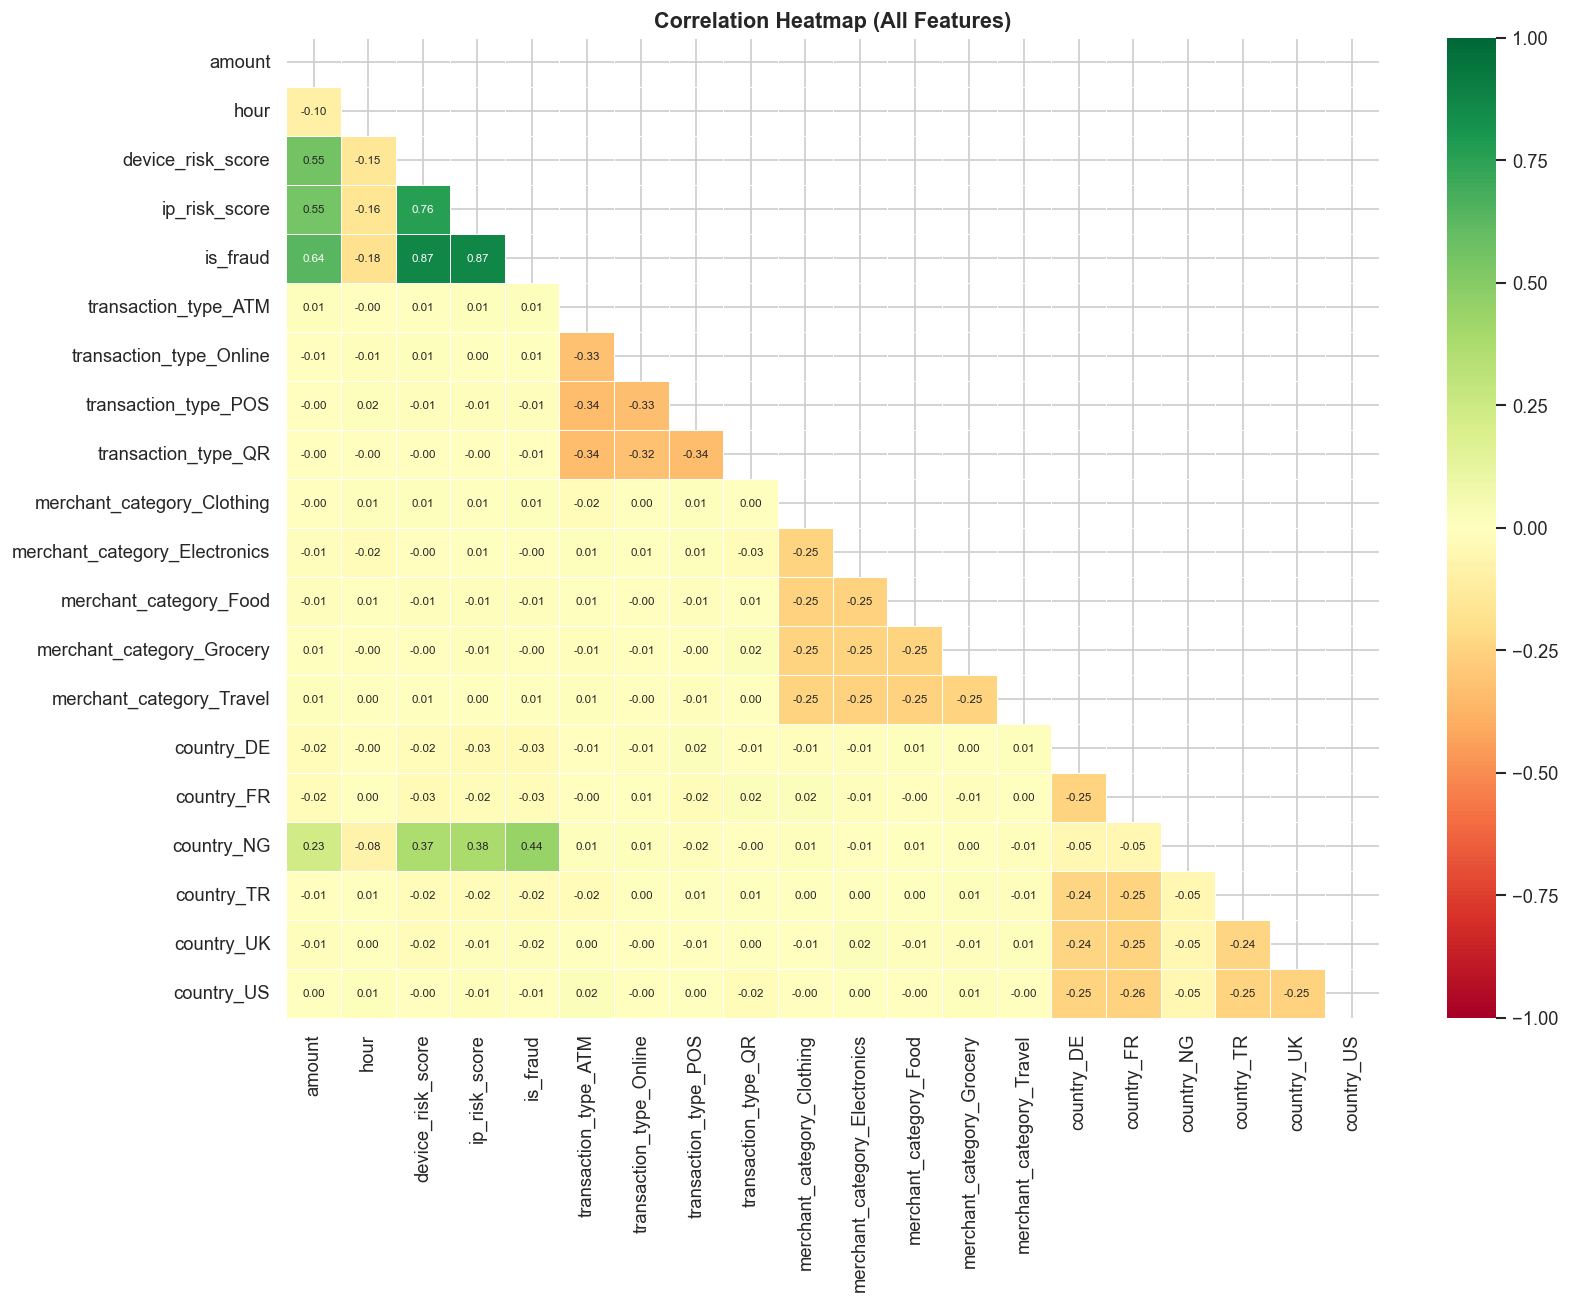

In [9]:
# Encode categoricals for correlation
df_encoded = pd.get_dummies(df.drop(columns=['transaction_id', 'user_id']), drop_first=False)

corr_matrix = df_encoded.corr()

# Full heatmap
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.4, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Correlation Heatmap (All Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

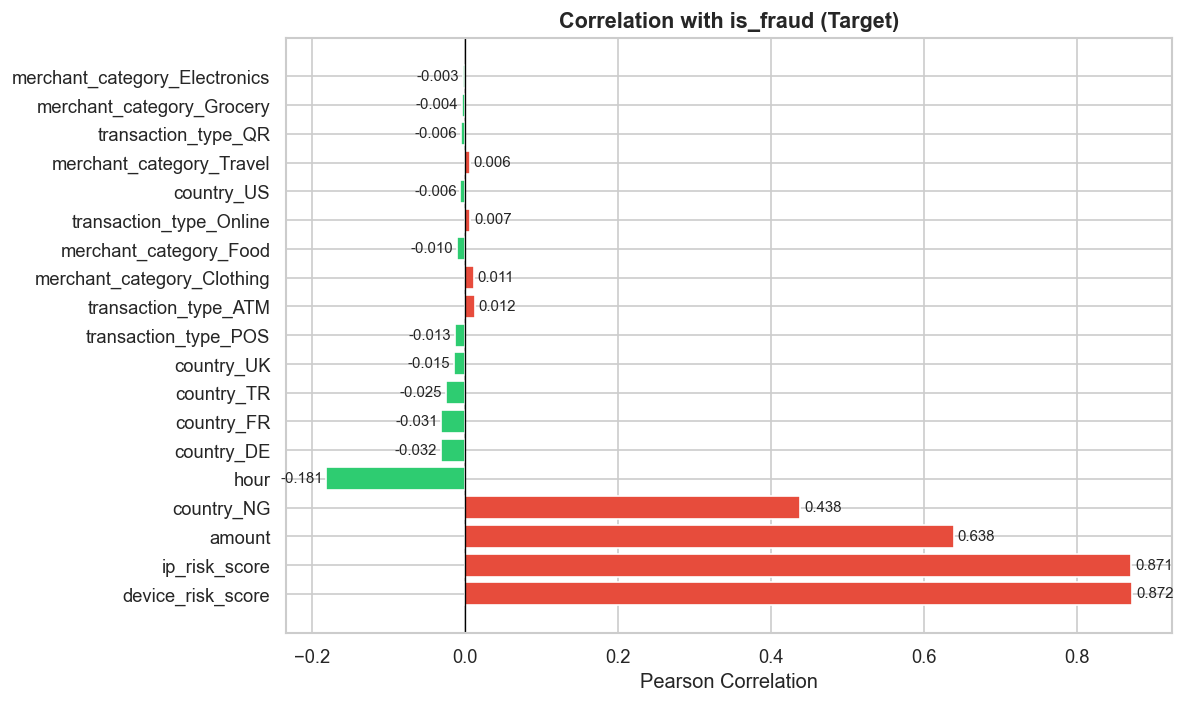

In [10]:
# Correlation with target variable
target_corr = corr_matrix['is_fraud'].drop('is_fraud').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [FRAUD_COLOR if v > 0 else LEGIT_COLOR for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation with is_fraud (Target)', fontweight='bold', fontsize=13)
ax.set_xlabel('Pearson Correlation')
for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

---
## 4. Fraud vs Non-Fraud Comparisons

In [11]:
fraud = df[df['is_fraud'] == 1]
legit = df[df['is_fraud'] == 0]

print('=== Summary Statistics by Class ===')
print('\n--- FRAUD ---')
print(fraud[num_cols].describe().round(3).to_string())
print('\n--- LEGITIMATE ---')
print(legit[num_cols].describe().round(3).to_string())

=== Summary Statistics by Class ===

--- FRAUD ---
          amount     hour  device_risk_score  ip_risk_score
count    500.000  500.000            500.000        500.000
mean    1657.578   10.018              0.858          0.852
std     1818.947    6.764              0.087          0.087
min       10.000    0.000              0.701          0.700
25%       22.168    4.000              0.783          0.776
50%     1220.564    9.000              0.855          0.856
75%     2508.133   16.000              0.938          0.927
max    11628.214   23.000              0.999          1.000

--- LEGITIMATE ---
         amount      hour  device_risk_score  ip_risk_score
count  9500.000  9500.000           9500.000       9500.000
mean    100.278    14.470              0.148          0.150
std      49.501     5.168              0.087          0.086
min       1.000     6.000              0.000          0.000
25%      65.180    10.000              0.072          0.074
50%     100.289    14.000    

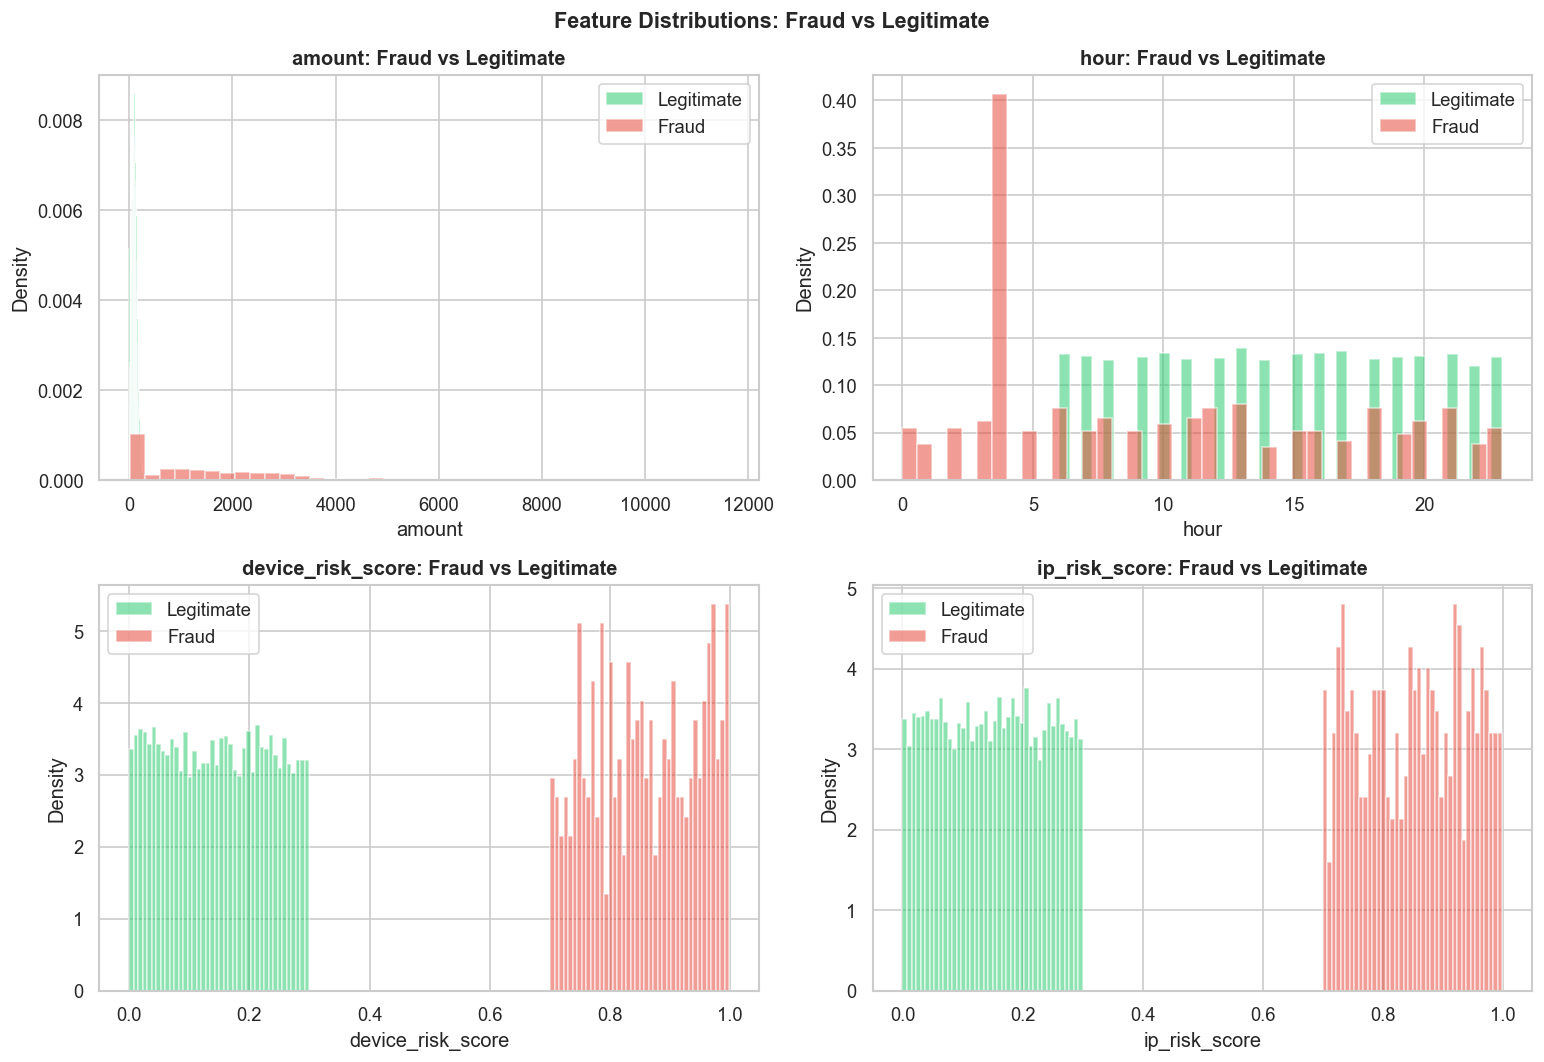

In [12]:
# KDE plots: Fraud vs Non-Fraud for numeric features
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(legit[col], bins=40, alpha=0.55, color=LEGIT_COLOR, label='Legitimate', density=True)
    axes[i].hist(fraud[col], bins=40, alpha=0.55, color=FRAUD_COLOR, label='Fraud', density=True)
    axes[i].set_title(f'{col}: Fraud vs Legitimate', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Feature Distributions: Fraud vs Legitimate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

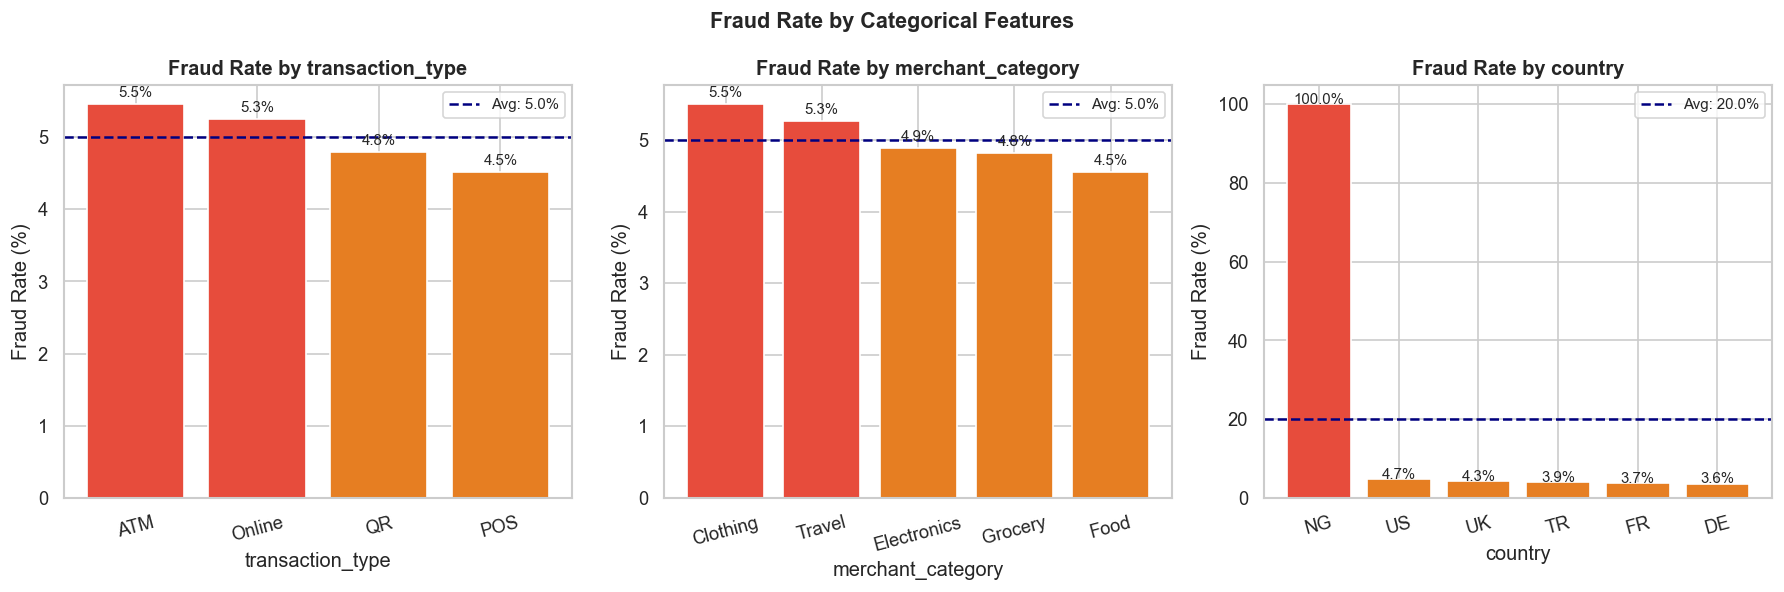

In [13]:
# Fraud rate by categorical features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols):
    fraud_rate = df.groupby(col)['is_fraud'].mean().sort_values(ascending=False) * 100
    bars = axes[i].bar(fraud_rate.index, fraud_rate.values,
                       color=[FRAUD_COLOR if v > fraud_rate.mean() else '#e67e22' for v in fraud_rate.values],
                       edgecolor='white')
    axes[i].axhline(fraud_rate.mean(), color='navy', linestyle='--', linewidth=1.5, label=f'Avg: {fraud_rate.mean():.1f}%')
    axes[i].set_title(f'Fraud Rate by {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fraud Rate (%)')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].legend(fontsize=9)
    for bar, val in zip(bars, fraud_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('Fraud Rate by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

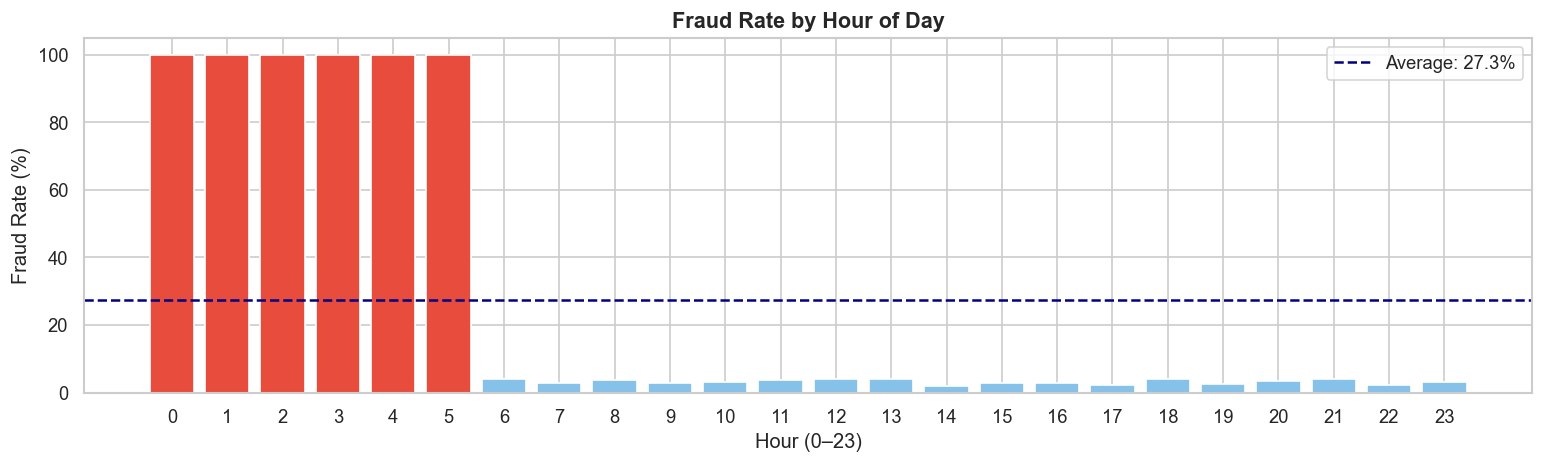

In [14]:
# Fraud rate by hour
hourly_fraud = df.groupby('hour')['is_fraud'].mean() * 100

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(hourly_fraud.index, hourly_fraud.values,
       color=[FRAUD_COLOR if v > hourly_fraud.mean() else '#85c1e9' for v in hourly_fraud.values],
       edgecolor='white')
ax.axhline(hourly_fraud.mean(), color='navy', linestyle='--', linewidth=1.5, label=f'Average: {hourly_fraud.mean():.1f}%')
ax.set_title('Fraud Rate by Hour of Day', fontweight='bold', fontsize=13)
ax.set_xlabel('Hour (0–23)')
ax.set_ylabel('Fraud Rate (%)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

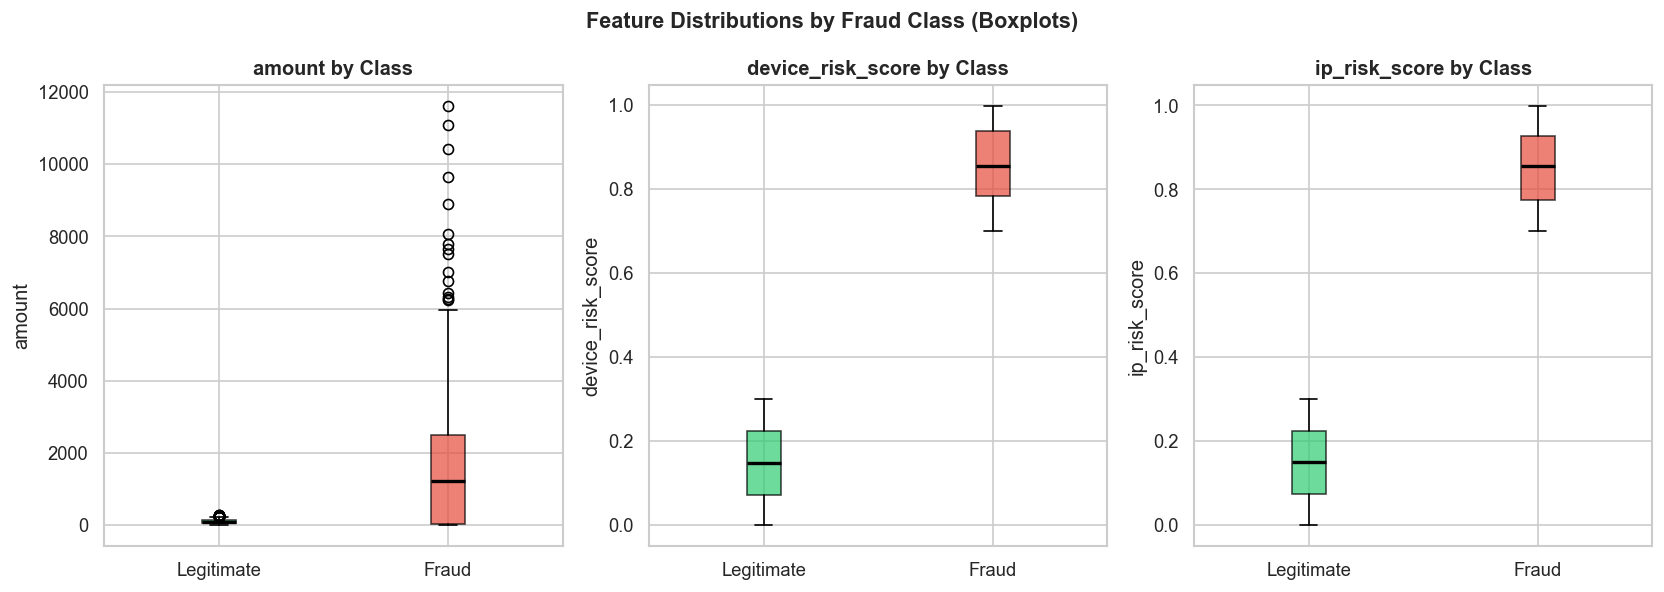

In [15]:
# Boxplots: amount and risk scores by fraud class
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(['amount', 'device_risk_score', 'ip_risk_score']):
    data_to_plot = [legit[col].values, fraud[col].values]
    bp = axes[i].boxplot(data_to_plot, patch_artist=True, labels=['Legitimate', 'Fraud'],
                         medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(LEGIT_COLOR)
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(FRAUD_COLOR)
    bp['boxes'][1].set_alpha(0.7)
    axes[i].set_title(f'{col} by Class', fontweight='bold')
    axes[i].set_ylabel(col)

plt.suptitle('Feature Distributions by Fraud Class (Boxplots)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Outlier Detection

In [16]:
# IQR-based outlier detection
print('=== IQR-Based Outlier Detection ===')
outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_pct = len(outliers) / len(df) * 100
    outlier_summary.append({
        'Feature': col, 'Q1': round(Q1, 4), 'Q3': round(Q3, 4),
        'IQR': round(IQR, 4), 'Lower Fence': round(lower, 4),
        'Upper Fence': round(upper, 4), 'Outlier Count': len(outliers),
        'Outlier %': round(outlier_pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

=== IQR-Based Outlier Detection ===
          Feature      Q1       Q3     IQR  Lower Fence  Upper Fence  Outlier Count  Outlier %
           amount 65.0848 138.2809 73.1961     -44.7094     248.0751            364       3.64
             hour 10.0000  19.0000  9.0000      -3.5000      32.5000              0       0.00
device_risk_score  0.0757   0.2349  0.1592      -0.1631       0.4738            500       5.00
    ip_risk_score  0.0778   0.2370  0.1592      -0.1610       0.4758            500       5.00


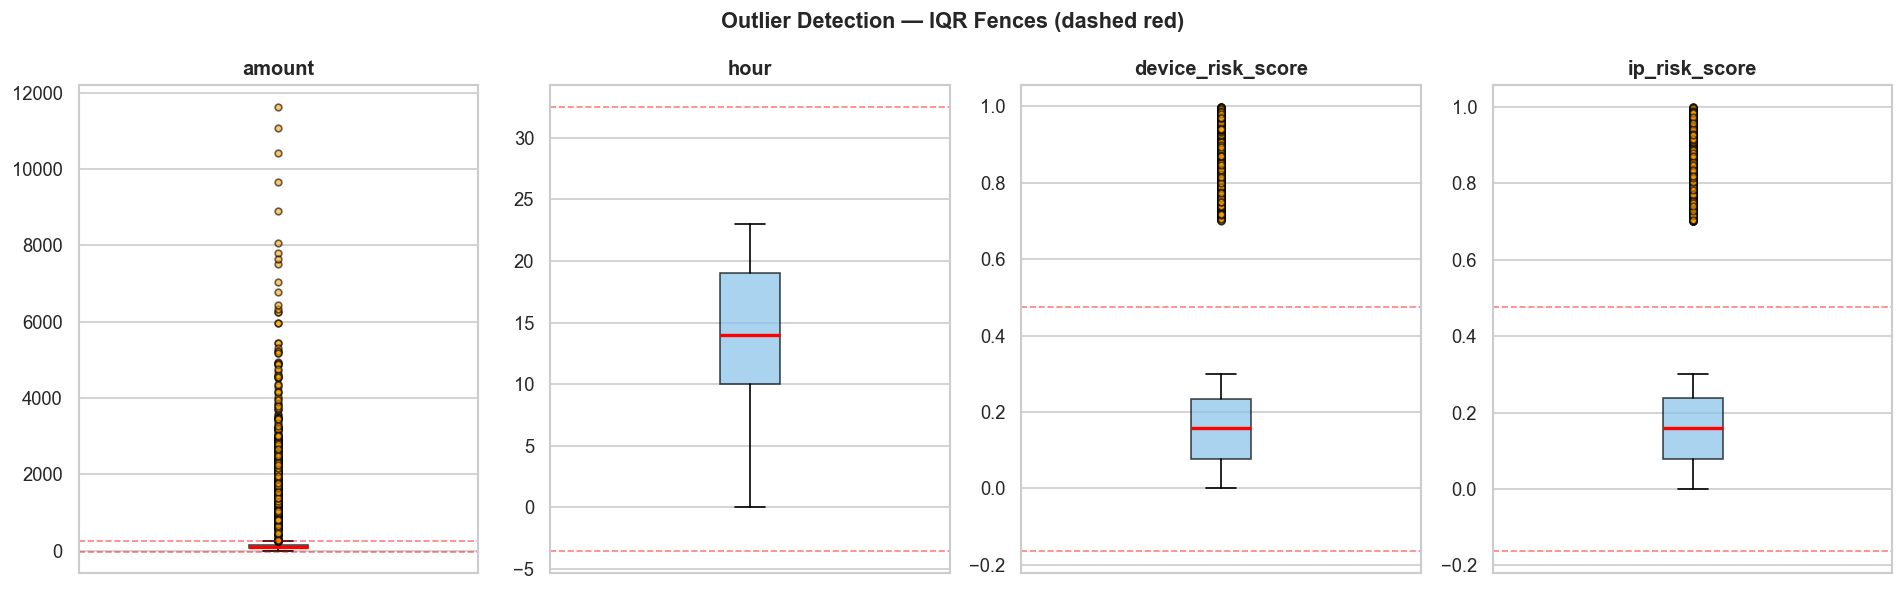

In [17]:
# Visualise outliers with boxplots per class
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(num_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    bp = axes[i].boxplot(df[col], patch_artist=True, vert=True,
                         boxprops=dict(facecolor='#85c1e9', alpha=0.7),
                         medianprops=dict(color='red', linewidth=2),
                         flierprops=dict(marker='o', markerfacecolor='orange',
                                         markersize=4, alpha=0.6))
    axes[i].axhline(lower, color='red', linestyle='--', linewidth=1, alpha=0.5, label='IQR fence')
    axes[i].axhline(upper, color='red', linestyle='--', linewidth=1, alpha=0.5)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xticks([])

plt.suptitle('Outlier Detection — IQR Fences (dashed red)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Z-score outliers (|z| > 3)
from scipy import stats

print('=== Z-Score Outliers (|z| > 3) ===')
for col in num_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    z_outliers = (z_scores > 3).sum()
    print(f'{col}: {z_outliers} outliers ({z_outliers/len(df)*100:.2f}%)')

=== Z-Score Outliers (|z| > 3) ===
amount: 187 outliers (1.87%)
hour: 0 outliers (0.00%)
device_risk_score: 479 outliers (4.79%)
ip_risk_score: 483 outliers (4.83%)


=== Top 1% High-Value Transactions (amount > $2836.91) ===
Count: 100
Fraud rate in high-value: 100.0%
Fraud rate overall:       5.0%


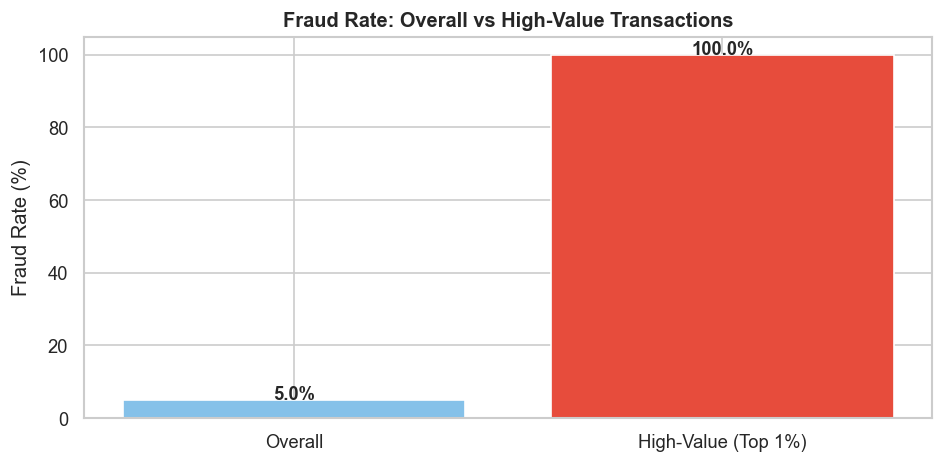

In [19]:
# High-value transaction analysis
amount_99 = df['amount'].quantile(0.99)
high_value = df[df['amount'] > amount_99]

print(f'=== Top 1% High-Value Transactions (amount > ${amount_99:.2f}) ===')
print(f'Count: {len(high_value):,}')
print(f'Fraud rate in high-value: {high_value["is_fraud"].mean()*100:.1f}%')
print(f'Fraud rate overall:       {df["is_fraud"].mean()*100:.1f}%')

fig, ax = plt.subplots(figsize=(8, 4))
rates = [
    df['is_fraud'].mean() * 100,
    high_value['is_fraud'].mean() * 100
]
bars = ax.bar(['Overall', 'High-Value (Top 1%)'], rates,
              color=['#85c1e9', FRAUD_COLOR], edgecolor='white')
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{rate:.1f}%', ha='center', fontweight='bold')
ax.set_title('Fraud Rate: Overall vs High-Value Transactions', fontweight='bold')
ax.set_ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.show()

---
## 6. Summary Insights

| # | Finding |
|---|---|
| 1 | **Class Imbalance** — Only 5% (500/10,000) of transactions are fraudulent. SMOTE or class weighting is needed for modelling. |
| 2 | **Risk Scores are strong signals** — `device_risk_score` and `ip_risk_score` are notably higher in fraudulent transactions. |
| 3 | **Amount** — Fraudulent transactions tend to involve higher amounts; outliers in `amount` are disproportionately fraud. |
| 4 | **Country** — Fraud rates differ across countries; some countries show above-average fraud rates. |
| 5 | **Transaction Type** — Certain transaction types (e.g. ATM) may carry higher fraud risk than others. |
| 6 | **Hour** — No strongly dominant fraud hour, but slight variation exists across the day. |
| 7 | **Outliers** — The `amount` column has the most IQR-based outliers; these overlap with high fraud rates. |